### author by yangshichen
### 注意：脚本仅供参考，使用前请仔细阅读

In [9]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn as sns
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
from scipy.io import mmread
from scipy.sparse import csr_matrix
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
from scipy.sparse import issparse
import decoupler as dc
from sklearn.preprocessing import QuantileTransformer
from multiprocessing import Pool, cpu_count
from functools import partial
from sklearn.preprocessing import QuantileTransformer, StandardScaler
quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=0)
scaler = StandardScaler()

import warnings
warnings.filterwarnings("ignore")

In [10]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=100, frameon=False)
sc._settings.ScanpyConfig.n_jobs=70

scanpy==1.9.8 anndata==0.9.2 umap==0.5.7 numpy==1.24.4 scipy==1.10.1 pandas==2.0.3 scikit-learn==1.3.2 statsmodels==0.14.1 pynndescent==0.5.13


In [11]:
import os
os.environ["R_HOME"] = "/home/yangshichen//mambaforge/envs/QTL/lib/R"
os.environ["R_LIBS_USER"] = "/home/yangshichen/mambaforge/envs/QTL/lib/R/library"
import pandas as pd
import torch
import tensorqtl
from tensorqtl import  cis
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch: {torch.__version__} (CUDA {torch.version.cuda}), device: {device}")
print(f"pandas: {pd.__version__}")

torch: 2.4.1+cu121 (CUDA 12.1), device: cpu
pandas: 2.0.3


### scRNA-seq数据处理 #848样本

#### 伪bulk数据，基因在75%样本中表达

In [13]:
adata=sc.read("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/Pseudobulk_scRNA_L4_filtered_donor.h5ad")
adata

AnnData object with n_obs × n_vars = 72146 × 38606
    obs: 'Classification_L4', 'ClinicalID'

In [14]:
len(adata.obs['Classification_L4'].unique())

99

In [15]:
len(adata.obs['ClinicalID'].unique())

848

In [16]:
sample = pd.read_csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/sample.csv")
sample

,WGSID,Gender,Age,ClinicalID,Batch,Pregnancy,Plate ID
0,HP-1,Female,85,D0649,B8,NO,INF-20241127-10
1,HP-10,Female,89,D0216,B37,NO,INF-20241127-11
2,HP-101,Male,29,D0721,B20,NO,INF-20241127-1
3,HP-103,Male,40,D0624,B20,NO,INF-20241127-1
4,HP-104,Female,33,D0167,B20,NO,INF-20241127-1
...,...,...,...,...,...,...,...
843,HP-954,Male,28,D0235,B25,NO,INF-20241127-1
844,HP-955,Female,40,D0578,B66,NO,INF-20241127-1
845,HP-956,Male,36,D0482,B66,NO,INF-20241127-1
846,HP-957,Male,47,D0501,B40,NO,INF-20241127-1


In [17]:
mapping = sample.set_index("ClinicalID")["WGSID"].to_dict()
adata.obs["DonorID"] = adata.obs["ClinicalID"].map(mapping)
adata.obs

,Classification_L4,ClinicalID,DonorID
ASDC_D0009,ASDC,D0009,HP-253
ASDC_D0010,ASDC,D0010,HP-778
ASDC_D0011,ASDC,D0011,HP-263
ASDC_D0012,ASDC,D0012,HP-431
ASDC_D0013,ASDC,D0013,HP-869
...,...,...,...
D0957_IFIT2- RNF213- NDNs,IFIT2- RNF213- NDNs,D0957,HP-825
D0957_IRF1- GBP2- NDNs,IRF1- GBP2- NDNs,D0957,HP-825
D0957_MT-ATP6- MT-CO2- NDNs,MT-ATP6- MT-CO2- NDNs,D0957,HP-825
D0957_RGS2- NDNs,RGS2- NDNs,D0957,HP-825


In [19]:
# 去除（X、Y、MT）染色体上的基因
annotation_df = pd.read_csv("/media/AnalysisDisk2/Yangshichen/0_HIV_RNA/QTL/Data/Genotype/gene_annotation.txt", sep='\t')
annotation_df = annotation_df[~annotation_df['chr'].isin(['chrX', 'chrY', 'chrMT'])].copy()
annotation_df

,gene_id,chr,left,right
0,DDX11L17,chr1,182696,184174
1,PRDM16,chr1,3069168,3438621
2,PEX10,chr1,2403964,2413797
3,RPL21P21,chr1,10054445,10054781
4,LINC01345,chr1,3944547,3949024
...,...,...,...,...
38660,ACTG1P14,chr9,6834456,6835577
38661,RPL4P5,chr9,7477045,7478320
38662,PPIAP33,chr9,7597823,7598377
38663,DMAC1,chr9,7796500,7888380


In [20]:
adata = adata[:, adata.var_names.isin(annotation_df['gene_id'])]
adata

View of AnnData object with n_obs × n_vars = 72146 × 24464
    obs: 'Classification_L4', 'ClinicalID', 'DonorID'

In [21]:
# 获取所有 celltype_L4 的唯一值
adata.obs['Classification_L4'] = adata.obs['Classification_L4'].str.replace('/', '_')
celltypes = adata.obs['Classification_L4'].unique()
celltypes

array(['ASDC', 'Adaptive NK cells', 'Atypical naïve B cells', 'Basophils',
       'CCR4+ CD8+ Tcm', 'CCR4- CD8+ Tcm', 'CD14+ cDC2', 'CD1C+ cDC2',
       'CD27+ IgD+ atypical memory B cells',
       'CD27+ IgD- atypical memory B cells', 'CD27+ MAIT', 'CD27+ Th17',
       'CD27+ Th1', 'CD27- IgD- atypical memory B cells', 'CD27- MAIT',
       'CD27- Th17', 'CD27- Th1', 'CD279+ SOX4+ Vδ1+ T cells',
       'CD4+ Temra', 'CD56+ MAIT', 'CD56bright NK cells',
       'CD56dim NK cells', 'CD62Lhi GZMK+ Vδ2+ T cells', 'CD8+ Temra',
       'CD8+ Treg', 'CD95 memory B cells', 'CILCP', 'CLP',
       'Core classical monocytes', 'DN T cells', 'Early memory B cells',
       'GBP1+ classical monocytes',
       'GZMB+ CD4+ terminal effector T cells', 'GZMB+ CD8+ Tem',
       'GZMB+ Vδ2+ T cells', 'GZMK+ CD8+ Tem', 'GZMK+ Vδ2+ T cells',
       'GZMK+ effector Vδ1+ T cells', 'HLA-DRhi CD4+ Treg',
       'HLA-DRhi CD4+ terminal effector T cells', 'HLA-DRhi CD8+ Tem',
       'HSC_MPP', 'IGKChi Plasma cells'

In [22]:
for celltype in celltypes:
    # 提取该细胞类型的子集
    adata_sub = adata[adata.obs['Classification_L4'] == celltype].copy()
    #adata_sub.X = adata_sub.layers['mean']

    #生成伪bulk矩阵
    pseudo_matrix = pd.DataFrame(adata_sub.X)
    pseudo_matrix.columns = adata_sub.var_names
    pseudo_matrix.index = adata_sub.obs['DonorID']

    #样本合并
    pseudo_matrix = pseudo_matrix.groupby(pseudo_matrix.index).mean()
    pseudo_matrix

    #只选取在75%的样本中都表达的特征
    non_zero_ratio = (pseudo_matrix != 0).mean()
    columns_to_keep = non_zero_ratio[non_zero_ratio >= 0.75].index
    pseudo_matrix = pseudo_matrix[columns_to_keep]

    # 计算每列的均值和标准差
    means = pseudo_matrix.mean()
    stds = pseudo_matrix.std()
    # 计算变异系数
    cv = (stds / means).abs() * 100
    # 按变异系数从大到小排序
    sorted_columns = cv.sort_values(ascending=False).index
    # 选取变异系数最高的前2000列
    top_2000_columns = sorted_columns[:min(2000,pseudo_matrix.shape[1])]

    #保存数据
    if pseudo_matrix.shape[1] > 0:
        normalized_pseudo_matrix = quantile_transformer.fit_transform(pseudo_matrix)
        normalized_pseudo_matrix = scaler.fit_transform(normalized_pseudo_matrix)
        normalized_pseudo_matrix = pd.DataFrame(normalized_pseudo_matrix, columns=pseudo_matrix.columns,index=pseudo_matrix.index)
        normalized_pseudo_matrix.to_csv(f'/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/02.normal_dis/{celltype}.csv')
        normalized_pseudo_matrix[top_2000_columns].to_csv(f'/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/04.top2000_normal_dis/{celltype}.csv')
        pseudo_matrix.to_csv(f'/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/01.pseudobulk/{celltype}.csv')
        pseudo_matrix[top_2000_columns].to_csv(f'/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/03.top2000_pseudobulk/{celltype}.csv')
    print(f"处理完成 {celltype} (genes retained: {len(columns_to_keep)})", flush=True)

处理完成 ASDC (genes retained: 2289)
处理完成 Adaptive NK cells (genes retained: 13189)
处理完成 Atypical naïve B cells (genes retained: 1156)
处理完成 Basophils (genes retained: 2678)
处理完成 CCR4+ CD8+ Tcm (genes retained: 8545)
处理完成 CCR4- CD8+ Tcm (genes retained: 4827)
处理完成 CD14+ cDC2 (genes retained: 9765)
处理完成 CD1C+ cDC2 (genes retained: 10342)
处理完成 CD27+ IgD+ atypical memory B cells (genes retained: 5018)
处理完成 CD27+ IgD- atypical memory B cells (genes retained: 1442)
处理完成 CD27+ MAIT (genes retained: 8622)
处理完成 CD27+ Th17 (genes retained: 11654)
处理完成 CD27+ Th1 (genes retained: 8610)
处理完成 CD27- IgD- atypical memory B cells (genes retained: 1931)
处理完成 CD27- MAIT (genes retained: 2964)
处理完成 CD27- Th17 (genes retained: 8131)
处理完成 CD27- Th1 (genes retained: 5239)
处理完成 CD279+ SOX4+ Vδ1+ T cells (genes retained: 411)
处理完成 CD4+ Temra (genes retained: 777)
处理完成 CD56+ MAIT (genes retained: 216)
处理完成 CD56bright NK cells (genes retained: 10494)
处理完成 CD56dim NK cells (genes retained: 13603)
处理完成 CD62Lhi GZMK+ V

In [23]:
# 设置目标文件夹路径
folder_path = '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/02.normal_dis/'  # 修改为你的实际路径

# 创建一个列表存储文件名和行数
file_counts = []

# 遍历文件夹中的所有CSV文件
for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        file_path = os.path.join(folder_path, file)
        try:
            row_count = sum(1 for _ in open(file_path)) - 1  # 减去标题行
            file_counts.append((file, row_count))
        except Exception as e:
            print(f"Error reading {file}: {e}")

# 转换为 DataFrame 并排序
df_counts = pd.DataFrame(file_counts, columns=['filename', 'row_count'])
df_counts = df_counts.sort_values(by='row_count', ascending=True).reset_index(drop=True)

# 打印或保存结果
print(df_counts)

                                    filename  row_count
0                              LAMP3+ DC.csv        123
1             Proliferative Vδ2+ T cells.csv        125
2                                    MEP.csv        127
3   Proliferative cytotoxic CD4+ T cells.csv        183
4                             CD56+ MAIT.csv        263
..                                       ...        ...
94                    ALPL- MARCKS- NDNs.csv        845
95                 MT-ATP6- MT-CO2- NDNs.csv        847
96                             Core NDNs.csv        848
97                      IRF1- GBP2- NDNs.csv        848
98                    CXCL8- PTGS2+ NDNs.csv        848

[99 rows x 2 columns]


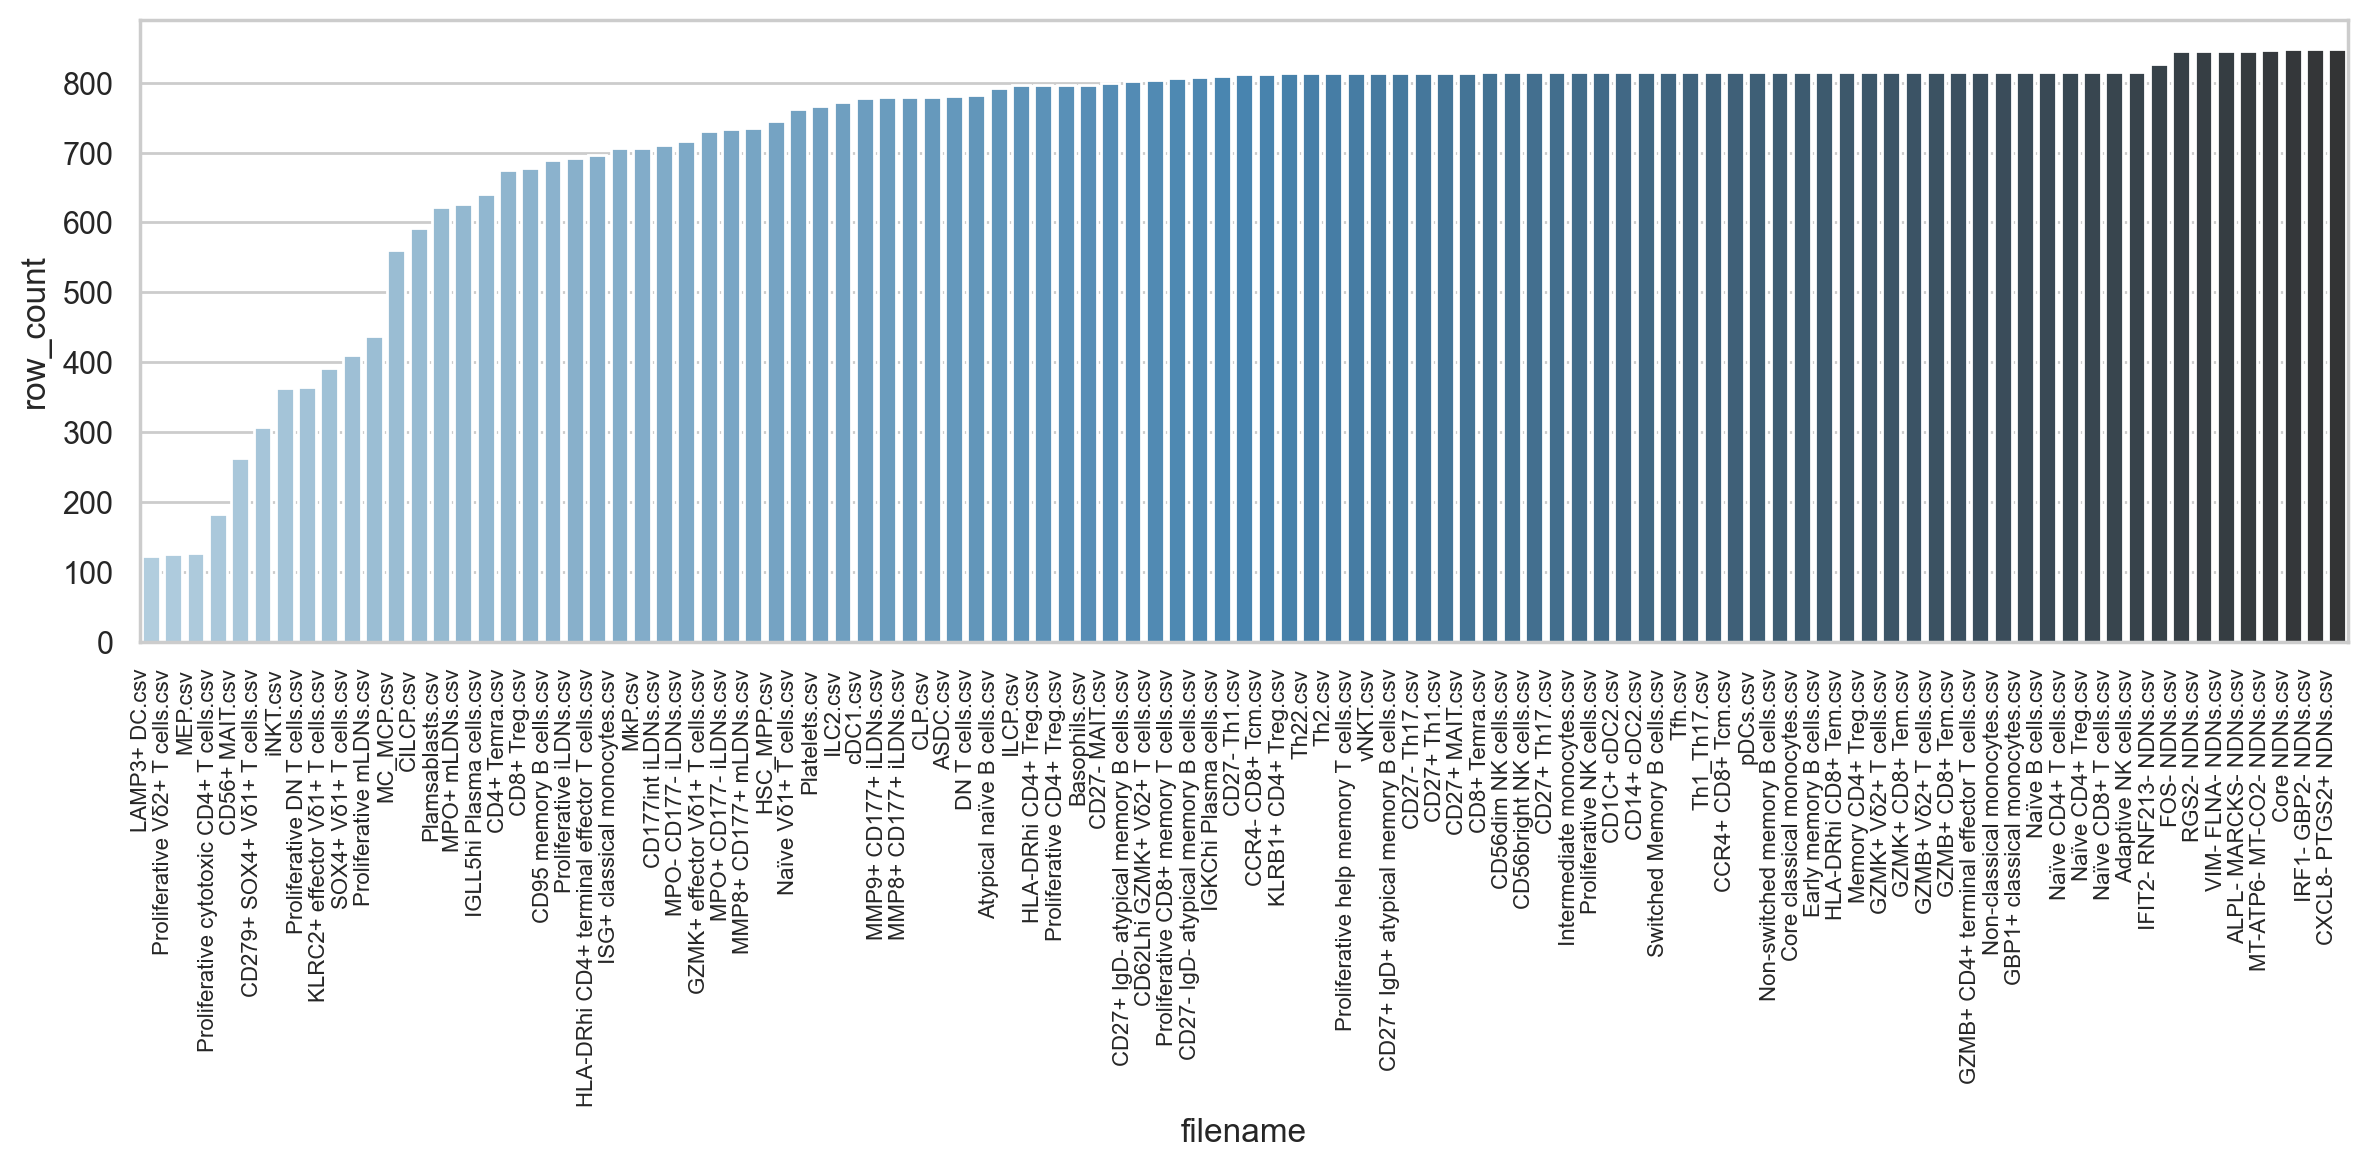

In [24]:
# 设置图形风格
sns.set(style="whitegrid")

# 画条形图
plt.figure(figsize=(12, 6))
sns.barplot(data=df_counts, x='filename', y='row_count', palette="Blues_d")

# 设置标签和标题
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.tight_layout()

# 显示图
plt.show()

#### 过滤掉低于80个样本的细胞类型

In [25]:
# 设置目录路径
input_dir = '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/01.pseudobulk/'

# 阈值设置
min_sample_threshold = 80

# 扫描所有 csv 文件
csv_files = [f for f in os.listdir(input_dir) if f.endswith('.csv')]

# 统计样本数，并删除样本数过少的文件
for file in csv_files:
    filepath = os.path.join(input_dir, file)
    df = pd.read_csv(filepath, index_col=0)
    
    sample_count = df.shape[0]
    
    if sample_count < min_sample_threshold:
        os.remove(filepath)
        print(f"[🗑️] Removed {file} — only {sample_count} samples")
    else:
        print(f"[✓] Kept {file} — {sample_count} samples")

[✓] Kept Adaptive NK cells.csv — 815 samples
[✓] Kept ALPL- MARCKS- NDNs.csv — 845 samples
[✓] Kept ASDC.csv — 781 samples
[✓] Kept Atypical naïve B cells.csv — 793 samples
[✓] Kept Basophils.csv — 797 samples
[✓] Kept CCR4+ CD8+ Tcm.csv — 815 samples
[✓] Kept CCR4- CD8+ Tcm.csv — 813 samples
[✓] Kept CD14+ cDC2.csv — 815 samples
[✓] Kept CD177int iLDNs.csv — 711 samples
[✓] Kept CD1C+ cDC2.csv — 815 samples
[✓] Kept CD27+ IgD+ atypical memory B cells.csv — 814 samples
[✓] Kept CD27+ IgD- atypical memory B cells.csv — 803 samples
[✓] Kept CD27+ MAIT.csv — 814 samples
[✓] Kept CD27+ Th1.csv — 814 samples
[✓] Kept CD27+ Th17.csv — 815 samples
[✓] Kept CD27- IgD- atypical memory B cells.csv — 808 samples
[✓] Kept CD27- MAIT.csv — 800 samples
[✓] Kept CD27- Th1.csv — 812 samples
[✓] Kept CD27- Th17.csv — 814 samples
[✓] Kept CD279+ SOX4+ Vδ1+ T cells.csv — 308 samples
[✓] Kept CD4+ Temra.csv — 675 samples
[✓] Kept CD56+ MAIT.csv — 263 samples
[✓] Kept CD56bright NK cells.csv — 815 samples


In [26]:
# 设置目录路径
input_dir = '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/02.normal_dis/'

# 阈值设置
min_sample_threshold = 80

# 扫描所有 csv 文件
csv_files = [f for f in os.listdir(input_dir) if f.endswith('.csv')]

# 统计样本数，并删除样本数过少的文件
for file in csv_files:
    filepath = os.path.join(input_dir, file)
    df = pd.read_csv(filepath, index_col=0)
    
    sample_count = df.shape[0]
    
    if sample_count < min_sample_threshold:
        os.remove(filepath)
        print(f"[🗑️] Removed {file} — only {sample_count} samples")
    else:
        print(f"[✓] Kept {file} — {sample_count} samples")

[✓] Kept Adaptive NK cells.csv — 815 samples
[✓] Kept ALPL- MARCKS- NDNs.csv — 845 samples
[✓] Kept ASDC.csv — 781 samples
[✓] Kept Atypical naïve B cells.csv — 793 samples
[✓] Kept Basophils.csv — 797 samples
[✓] Kept CCR4+ CD8+ Tcm.csv — 815 samples
[✓] Kept CCR4- CD8+ Tcm.csv — 813 samples
[✓] Kept CD14+ cDC2.csv — 815 samples
[✓] Kept CD177int iLDNs.csv — 711 samples
[✓] Kept CD1C+ cDC2.csv — 815 samples
[✓] Kept CD27+ IgD+ atypical memory B cells.csv — 814 samples
[✓] Kept CD27+ IgD- atypical memory B cells.csv — 803 samples
[✓] Kept CD27+ MAIT.csv — 814 samples
[✓] Kept CD27+ Th1.csv — 814 samples
[✓] Kept CD27+ Th17.csv — 815 samples
[✓] Kept CD27- IgD- atypical memory B cells.csv — 808 samples
[✓] Kept CD27- MAIT.csv — 800 samples
[✓] Kept CD27- Th1.csv — 812 samples
[✓] Kept CD27- Th17.csv — 814 samples
[✓] Kept CD279+ SOX4+ Vδ1+ T cells.csv — 308 samples
[✓] Kept CD4+ Temra.csv — 675 samples
[✓] Kept CD56+ MAIT.csv — 263 samples
[✓] Kept CD56bright NK cells.csv — 815 samples


In [27]:
# 设置目录路径
input_dir = '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/03.top2000_pseudobulk/'

# 阈值设置
min_sample_threshold = 80

# 扫描所有 csv 文件
csv_files = [f for f in os.listdir(input_dir) if f.endswith('.csv')]

# 统计样本数，并删除样本数过少的文件
for file in csv_files:
    filepath = os.path.join(input_dir, file)
    df = pd.read_csv(filepath, index_col=0)
    
    sample_count = df.shape[0]
    
    if sample_count < min_sample_threshold:
        os.remove(filepath)
        print(f"[🗑️] Removed {file} — only {sample_count} samples")
    else:
        print(f"[✓] Kept {file} — {sample_count} samples")

[✓] Kept Adaptive NK cells.csv — 815 samples
[✓] Kept ALPL- MARCKS- NDNs.csv — 845 samples
[✓] Kept ASDC.csv — 781 samples
[✓] Kept Atypical naïve B cells.csv — 793 samples
[✓] Kept Basophils.csv — 797 samples
[✓] Kept CCR4+ CD8+ Tcm.csv — 815 samples
[✓] Kept CCR4- CD8+ Tcm.csv — 813 samples
[✓] Kept CD14+ cDC2.csv — 815 samples
[✓] Kept CD177int iLDNs.csv — 711 samples
[✓] Kept CD1C+ cDC2.csv — 815 samples
[✓] Kept CD27+ IgD+ atypical memory B cells.csv — 814 samples
[✓] Kept CD27+ IgD- atypical memory B cells.csv — 803 samples
[✓] Kept CD27+ MAIT.csv — 814 samples
[✓] Kept CD27+ Th1.csv — 814 samples
[✓] Kept CD27+ Th17.csv — 815 samples
[✓] Kept CD27- IgD- atypical memory B cells.csv — 808 samples
[✓] Kept CD27- MAIT.csv — 800 samples
[✓] Kept CD27- Th1.csv — 812 samples
[✓] Kept CD27- Th17.csv — 814 samples
[✓] Kept CD279+ SOX4+ Vδ1+ T cells.csv — 308 samples
[✓] Kept CD4+ Temra.csv — 675 samples
[✓] Kept CD56+ MAIT.csv — 263 samples
[✓] Kept CD56bright NK cells.csv — 815 samples


In [28]:
# 设置目录路径
input_dir = '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/04.top2000_normal_dis/'

# 阈值设置
min_sample_threshold = 80

# 扫描所有 csv 文件
csv_files = [f for f in os.listdir(input_dir) if f.endswith('.csv')]

# 统计样本数，并删除样本数过少的文件
for file in csv_files:
    filepath = os.path.join(input_dir, file)
    df = pd.read_csv(filepath, index_col=0)
    
    sample_count = df.shape[0]
    
    if sample_count < min_sample_threshold:
        os.remove(filepath)
        print(f"[🗑️] Removed {file} — only {sample_count} samples")
    else:
        print(f"[✓] Kept {file} — {sample_count} samples")

[✓] Kept Adaptive NK cells.csv — 815 samples
[✓] Kept ALPL- MARCKS- NDNs.csv — 845 samples
[✓] Kept ASDC.csv — 781 samples
[✓] Kept Atypical naïve B cells.csv — 793 samples
[✓] Kept Basophils.csv — 797 samples
[✓] Kept CCR4+ CD8+ Tcm.csv — 815 samples
[✓] Kept CCR4- CD8+ Tcm.csv — 813 samples
[✓] Kept CD14+ cDC2.csv — 815 samples
[✓] Kept CD177int iLDNs.csv — 711 samples
[✓] Kept CD1C+ cDC2.csv — 815 samples
[✓] Kept CD27+ IgD+ atypical memory B cells.csv — 814 samples
[✓] Kept CD27+ IgD- atypical memory B cells.csv — 803 samples
[✓] Kept CD27+ MAIT.csv — 814 samples
[✓] Kept CD27+ Th1.csv — 814 samples
[✓] Kept CD27+ Th17.csv — 815 samples
[✓] Kept CD27- IgD- atypical memory B cells.csv — 808 samples
[✓] Kept CD27- MAIT.csv — 800 samples
[✓] Kept CD27- Th1.csv — 812 samples
[✓] Kept CD27- Th17.csv — 814 samples
[✓] Kept CD279+ SOX4+ Vδ1+ T cells.csv — 308 samples
[✓] Kept CD4+ Temra.csv — 675 samples
[✓] Kept CD56+ MAIT.csv — 263 samples
[✓] Kept CD56bright NK cells.csv — 815 samples


#### PEER（识别基因表达数据中潜在的隐藏协变量）

In [19]:
'''
参见代码:02.tensorQTL-data_PEER.ipynb
'''

'\n参见代码:02.tensorQTL-data_PEER.ipynb\n'

#### 每个基因的残差表达

In [2]:
'''
参见代码:02.tensorQTL-scRNA_PEER.ipynb
'''

'\n参见代码:02.tensorQTL-scRNA_PEER.ipynb\n'

### scADT-seq数据处理

#### 伪bulk数据，蛋白在90%样本中表达

In [21]:
adata=sc.read("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/scADT-seq/Pseudobulk_scADT_L4_filtered_donor.h5ad")
adata

AnnData object with n_obs × n_vars = 137631 × 30
    obs: 'Classification_L4', 'SampleID', 'ClinicalID', 'DonorID'
    layers: 'count_nonzero', 'mean', 'sum'

In [25]:
adata.obs

,Classification_L4,SampleID,ClinicalID,DonorID
ASDC_D0009_Rep1,ASDC,D0009_Rep1,D0009,HP-253
ASDC_D0009_Rep2,ASDC,D0009_Rep2,D0009,HP-253
ASDC_D0010_Rep1,ASDC,D0010_Rep1,D0010,HP-778
ASDC_D0010_Rep2,ASDC,D0010_Rep2,D0010,HP-778
ASDC_D0011_Rep1,ASDC,D0011_Rep1,D0011,HP-263
...,...,...,...,...
vNKT_D0955_M_Rep2,vNKT,D0955_M_Rep2,D0955_M,HP-944
vNKT_D0956_Rep1,vNKT,D0956_Rep1,D0956,HP-262
vNKT_D0956_Rep2,vNKT,D0956_Rep2,D0956,HP-262
vNKT_D0957_Rep1,vNKT,D0957_Rep1,D0957,HP-825


In [24]:
# 获取所有 celltype_L3 的唯一值
adata.obs['Classification_L4'] = adata.obs['Classification_L4'].str.replace('/', '_')
celltypes = adata_filtered.obs['Classification_L4'].unique()
celltypes

array(['ASDC', 'Adaptive NK cells', 'Atypical naïve B cells', 'Basophils',
       'CCR4+ CD8+ Tcm', 'CCR4- CD8+ Tcm', 'CD1C+ cDC2', 'CD4+ Temra',
       'CD8+ Temra', 'CD8+ Treg', 'CD14+ cDC2',
       'CD27+ IgD+ atypical memory B cells',
       'CD27+ IgD- atypical memory B cells', 'CD27+ MAIT', 'CD27+ Th1',
       'CD27+ Th17', 'CD27- IgD- atypical memory B cells', 'CD27- MAIT',
       'CD27- Th1', 'CD27- Th17', 'CD56+ MAIT', 'CD56bright NK cells',
       'CD56dim NK cells', 'CD62Lhi GZMK+ Vδ2+ T cells',
       'CD95 memory B cells', 'CD279+ SOX4+ Vδ1+ T cells', 'CILCP', 'CLP',
       'CXCR4- CXCL8- mature neutrophils', 'Core classical monocytes',
       'Core mature neutrophils', 'DN T cells', 'Early memory B cells',
       'FOS- mature neutrophils', 'GBP1+ classical monocytes',
       'GZMB+ CD4+ terminal effector T cells', 'GZMB+ CD8+ Tem',
       'GZMB+ Vδ2+ T cells', 'GZMK+ CD8+ Tem', 'GZMK+ Vδ2+ T cells',
       'GZMK+ effector Vδ1+ T cells', 'HLA-DRhi CD4+ Treg',
       'HLA-D

In [33]:
for celltype in celltypes:
    # 提取该细胞类型的子集
    adata_sub = adata[adata.obs['Classification_L4'] == celltype].copy()
    adata_sub.X = adata_sub.layers['mean']

    #生成伪bulk矩阵
    pseudo_matrix = pd.DataFrame(adata_sub.X)
    pseudo_matrix.columns = adata_sub.var_names
    pseudo_matrix.index = adata_sub.obs['DonorID']

    #样本合并
    pseudo_matrix = pseudo_matrix.groupby(pseudo_matrix.index).mean()
    pseudo_matrix

    #只选取在90%的样本中都表达的特征
    non_zero_ratio = (pseudo_matrix != 0).mean()
    columns_to_keep = non_zero_ratio[non_zero_ratio >= 0.9].index
    pseudo_matrix = pseudo_matrix[columns_to_keep]

    # 计算每列的均值和标准差
    means = pseudo_matrix.mean()
    stds = pseudo_matrix.std()
    # 计算变异系数
    cv = (stds / means).abs() * 100
    # 按变异系数从大到小排序
    sorted_columns = cv.sort_values(ascending=False).index
    # 选取变异系数最高的前2000列
    top_2000_columns = sorted_columns[:min(2000,pseudo_matrix.shape[1])]

    #保存数据
    if pseudo_matrix.shape[1] > 0:
        normalized_pseudo_matrix = quantile_transformer.fit_transform(pseudo_matrix)
        normalized_pseudo_matrix = scaler.fit_transform(normalized_pseudo_matrix)
        normalized_pseudo_matrix = pd.DataFrame(normalized_pseudo_matrix, columns=pseudo_matrix.columns,index=pseudo_matrix.index)
        normalized_pseudo_matrix.to_csv(f'/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/scADT-seq/02.normal_dis/{celltype}.csv')
        normalized_pseudo_matrix[top_2000_columns].to_csv(f'/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/scADT-seq/04.top2000_normal_dis/{celltype}.csv')
        pseudo_matrix.to_csv(f'/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/scADT-seq/01.pseudobulk/{celltype}.csv')
        pseudo_matrix[top_2000_columns].to_csv(f'/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/scADT-seq/03.top2000_pseudobulk/{celltype}.csv')
    print(f"处理完成 {celltype} (genes retained: {len(columns_to_keep)})", flush=True)

处理完成 ASDC (genes retained: 13)
处理完成 Adaptive NK cells (genes retained: 30)
处理完成 Atypical naïve B cells (genes retained: 16)
处理完成 Basophils (genes retained: 28)
处理完成 CCR4+ CD8+ Tcm (genes retained: 29)
处理完成 CCR4- CD8+ Tcm (genes retained: 27)
处理完成 CD1C+ cDC2 (genes retained: 29)
处理完成 CD4+ Temra (genes retained: 15)
处理完成 CD8+ Temra (genes retained: 29)
处理完成 CD8+ Treg (genes retained: 8)
处理完成 CD14+ cDC2 (genes retained: 29)
处理完成 CD27+ IgD+ atypical memory B cells (genes retained: 27)
处理完成 CD27+ IgD- atypical memory B cells (genes retained: 16)
处理完成 CD27+ MAIT (genes retained: 29)
处理完成 CD27+ Th1 (genes retained: 29)
处理完成 CD27+ Th17 (genes retained: 30)
处理完成 CD27- IgD- atypical memory B cells (genes retained: 20)
处理完成 CD27- MAIT (genes retained: 22)
处理完成 CD27- Th1 (genes retained: 27)
处理完成 CD27- Th17 (genes retained: 29)
处理完成 CD56+ MAIT (genes retained: 10)
处理完成 CD56bright NK cells (genes retained: 29)
处理完成 CD56dim NK cells (genes retained: 30)
处理完成 CD62Lhi GZMK+ Vδ2+ T cells (genes retaine

In [34]:
# 设置目标文件夹路径
folder_path = '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/scADT-seq/02.normal_dis/'  # 修改为你的实际路径

# 创建一个列表存储文件名和行数
file_counts = []

# 遍历文件夹中的所有CSV文件
for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        file_path = os.path.join(folder_path, file)
        try:
            row_count = sum(1 for _ in open(file_path)) - 1  # 减去标题行
            file_counts.append((file, row_count))
        except Exception as e:
            print(f"Error reading {file}: {e}")

# 转换为 DataFrame 并排序
df_counts = pd.DataFrame(file_counts, columns=['filename', 'row_count'])
df_counts = df_counts.sort_values(by='row_count', ascending=True).reset_index(drop=True)

# 打印或保存结果
print(df_counts)

                                    filename  row_count
0                              LAMP3+ DC.csv        129
1             Proliferative Vδ2+ T cells.csv        131
2                                    MEP.csv        136
3   Proliferative cytotoxic CD4+ T cells.csv        184
4                             CD56+ MAIT.csv        288
..                                       ...        ...
91                        GZMB+ CD8+ Tem.csv        863
92  GZMB+ CD4+ terminal effector T cells.csv        863
93             GBP1+ classical monocytes.csv        863
94              Core classical monocytes.csv        863
95                     Adaptive NK cells.csv        863

[96 rows x 2 columns]


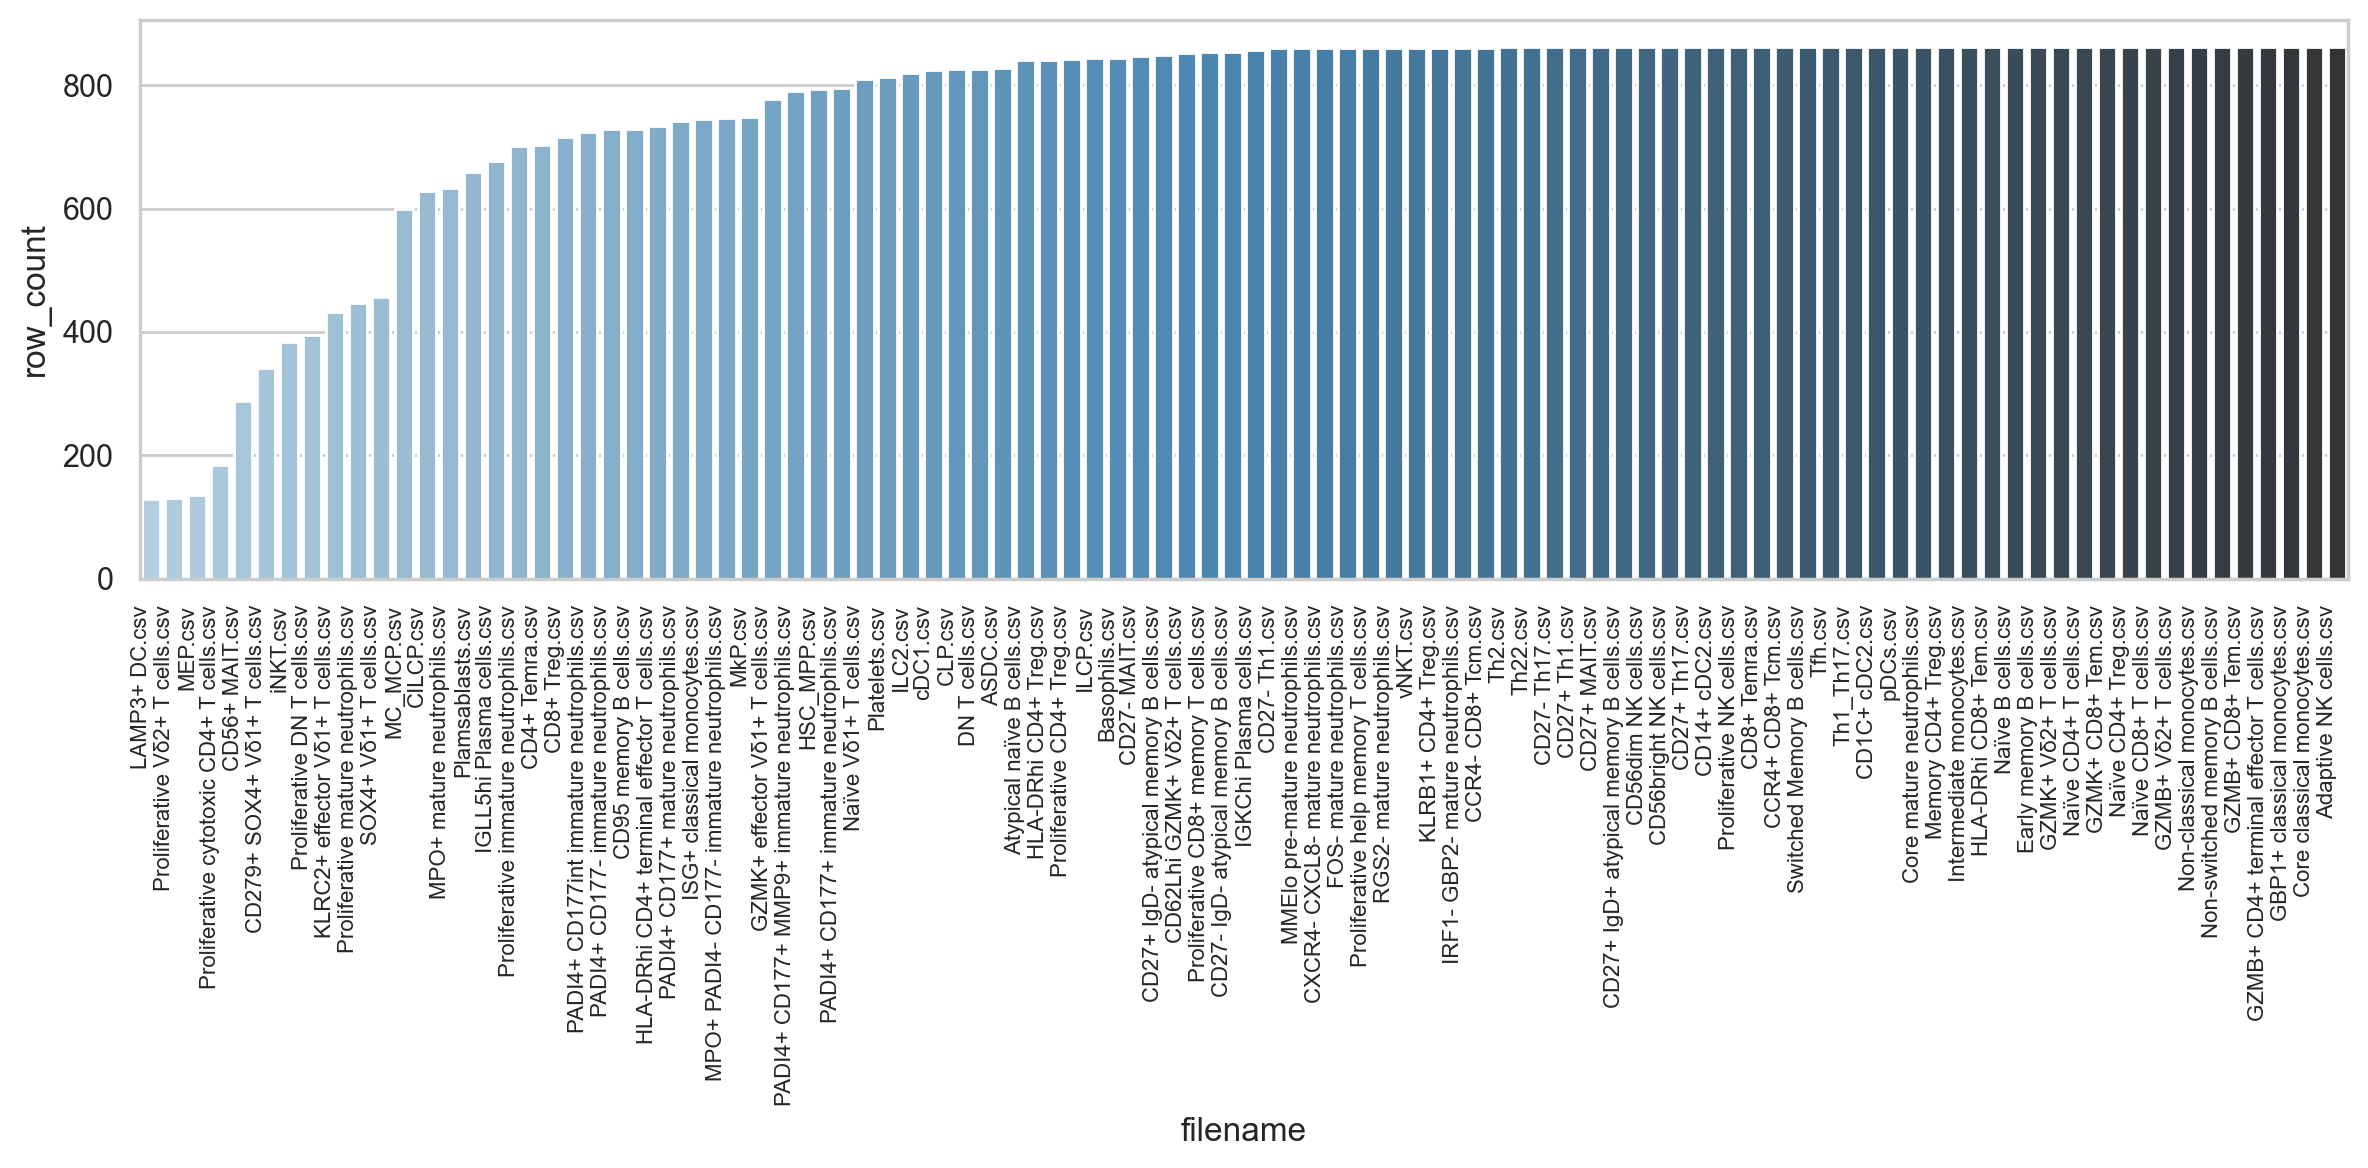

In [35]:
# 设置图形风格
sns.set(style="whitegrid")

# 画条形图
plt.figure(figsize=(12, 6))
sns.barplot(data=df_counts, x='filename', y='row_count', palette="Blues_d")

# 设置标签和标题
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.tight_layout()

# 显示图
plt.show()

#### 过滤掉低于80个样本的细胞类型

In [36]:
# 设置目录路径
input_dir = '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/scADT-seq/01.pseudobulk/'

# 阈值设置
min_sample_threshold = 80

# 扫描所有 csv 文件
csv_files = [f for f in os.listdir(input_dir) if f.endswith('.csv')]

# 统计样本数，并删除样本数过少的文件
for file in csv_files:
    filepath = os.path.join(input_dir, file)
    df = pd.read_csv(filepath, index_col=0)
    
    sample_count = df.shape[0]
    
    if sample_count < min_sample_threshold:
        os.remove(filepath)
        print(f"[🗑️] Removed {file} — only {sample_count} samples")
    else:
        print(f"[✓] Kept {file} — {sample_count} samples")

[✓] Kept Adaptive NK cells.csv — 863 samples
[✓] Kept ASDC.csv — 829 samples
[✓] Kept Atypical naïve B cells.csv — 841 samples
[✓] Kept Basophils.csv — 845 samples
[✓] Kept CCR4+ CD8+ Tcm.csv — 863 samples
[✓] Kept CCR4- CD8+ Tcm.csv — 861 samples
[✓] Kept CD14+ cDC2.csv — 863 samples
[✓] Kept CD1C+ cDC2.csv — 863 samples
[✓] Kept CD27+ IgD+ atypical memory B cells.csv — 862 samples
[✓] Kept CD27+ IgD- atypical memory B cells.csv — 850 samples
[✓] Kept CD27+ MAIT.csv — 862 samples
[✓] Kept CD27+ Th1.csv — 862 samples
[✓] Kept CD27+ Th17.csv — 863 samples
[✓] Kept CD27- IgD- atypical memory B cells.csv — 855 samples
[✓] Kept CD27- MAIT.csv — 848 samples
[✓] Kept CD27- Th1.csv — 860 samples
[✓] Kept CD279+ SOX4+ Vδ1+ T cells.csv — 342 samples
[✓] Kept CD4+ Temra.csv — 703 samples
[✓] Kept CD56+ MAIT.csv — 288 samples
[✓] Kept CD56bright NK cells.csv — 863 samples
[✓] Kept CD56dim NK cells.csv — 863 samples
[✓] Kept CD62Lhi GZMK+ Vδ2+ T cells.csv — 852 samples
[✓] Kept CD8+ Temra.csv — 86

In [37]:
# 设置目录路径
input_dir = '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/scADT-seq/02.normal_dis/'

# 阈值设置
min_sample_threshold = 80

# 扫描所有 csv 文件
csv_files = [f for f in os.listdir(input_dir) if f.endswith('.csv')]

# 统计样本数，并删除样本数过少的文件
for file in csv_files:
    filepath = os.path.join(input_dir, file)
    df = pd.read_csv(filepath, index_col=0)
    
    sample_count = df.shape[0]
    
    if sample_count < min_sample_threshold:
        os.remove(filepath)
        print(f"[🗑️] Removed {file} — only {sample_count} samples")
    else:
        print(f"[✓] Kept {file} — {sample_count} samples")

[✓] Kept Adaptive NK cells.csv — 863 samples
[✓] Kept ASDC.csv — 829 samples
[✓] Kept Atypical naïve B cells.csv — 841 samples
[✓] Kept Basophils.csv — 845 samples
[✓] Kept CCR4+ CD8+ Tcm.csv — 863 samples
[✓] Kept CCR4- CD8+ Tcm.csv — 861 samples
[✓] Kept CD14+ cDC2.csv — 863 samples
[✓] Kept CD1C+ cDC2.csv — 863 samples
[✓] Kept CD27+ IgD+ atypical memory B cells.csv — 862 samples
[✓] Kept CD27+ IgD- atypical memory B cells.csv — 850 samples
[✓] Kept CD27+ MAIT.csv — 862 samples
[✓] Kept CD27+ Th1.csv — 862 samples
[✓] Kept CD27+ Th17.csv — 863 samples
[✓] Kept CD27- IgD- atypical memory B cells.csv — 855 samples
[✓] Kept CD27- MAIT.csv — 848 samples
[✓] Kept CD27- Th1.csv — 860 samples
[✓] Kept CD279+ SOX4+ Vδ1+ T cells.csv — 342 samples
[✓] Kept CD4+ Temra.csv — 703 samples
[✓] Kept CD56+ MAIT.csv — 288 samples
[✓] Kept CD56bright NK cells.csv — 863 samples
[✓] Kept CD56dim NK cells.csv — 863 samples
[✓] Kept CD62Lhi GZMK+ Vδ2+ T cells.csv — 852 samples
[✓] Kept CD8+ Temra.csv — 86

In [38]:
# 设置目录路径
input_dir = '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/scADT-seq/03.top2000_pseudobulk/'

# 阈值设置
min_sample_threshold = 80

# 扫描所有 csv 文件
csv_files = [f for f in os.listdir(input_dir) if f.endswith('.csv')]

# 统计样本数，并删除样本数过少的文件
for file in csv_files:
    filepath = os.path.join(input_dir, file)
    df = pd.read_csv(filepath, index_col=0)
    
    sample_count = df.shape[0]
    
    if sample_count < min_sample_threshold:
        os.remove(filepath)
        print(f"[🗑️] Removed {file} — only {sample_count} samples")
    else:
        print(f"[✓] Kept {file} — {sample_count} samples")

[✓] Kept Adaptive NK cells.csv — 863 samples
[✓] Kept ASDC.csv — 829 samples
[✓] Kept Atypical naïve B cells.csv — 841 samples
[✓] Kept Basophils.csv — 845 samples
[✓] Kept CCR4+ CD8+ Tcm.csv — 863 samples
[✓] Kept CCR4- CD8+ Tcm.csv — 861 samples
[✓] Kept CD14+ cDC2.csv — 863 samples
[✓] Kept CD1C+ cDC2.csv — 863 samples
[✓] Kept CD27+ IgD+ atypical memory B cells.csv — 862 samples
[✓] Kept CD27+ IgD- atypical memory B cells.csv — 850 samples
[✓] Kept CD27+ MAIT.csv — 862 samples
[✓] Kept CD27+ Th1.csv — 862 samples
[✓] Kept CD27+ Th17.csv — 863 samples
[✓] Kept CD27- IgD- atypical memory B cells.csv — 855 samples
[✓] Kept CD27- MAIT.csv — 848 samples
[✓] Kept CD27- Th17.csv — 862 samples
[✓] Kept CD279+ SOX4+ Vδ1+ T cells.csv — 342 samples
[✓] Kept CD4+ Temra.csv — 703 samples
[✓] Kept CD56+ MAIT.csv — 288 samples
[✓] Kept CD56bright NK cells.csv — 863 samples
[✓] Kept CD56dim NK cells.csv — 863 samples
[✓] Kept CD62Lhi GZMK+ Vδ2+ T cells.csv — 852 samples
[✓] Kept CD8+ Temra.csv — 8

In [39]:
# 设置目录路径
input_dir = '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/scADT-seq/04.top2000_normal_dis/'

# 阈值设置
min_sample_threshold = 80

# 扫描所有 csv 文件
csv_files = [f for f in os.listdir(input_dir) if f.endswith('.csv')]

# 统计样本数，并删除样本数过少的文件
for file in csv_files:
    filepath = os.path.join(input_dir, file)
    df = pd.read_csv(filepath, index_col=0)
    
    sample_count = df.shape[0]
    
    if sample_count < min_sample_threshold:
        os.remove(filepath)
        print(f"[🗑️] Removed {file} — only {sample_count} samples")
    else:
        print(f"[✓] Kept {file} — {sample_count} samples")

[✓] Kept Adaptive NK cells.csv — 863 samples
[✓] Kept ASDC.csv — 829 samples
[✓] Kept Atypical naïve B cells.csv — 841 samples
[✓] Kept Basophils.csv — 845 samples
[✓] Kept CCR4+ CD8+ Tcm.csv — 863 samples
[✓] Kept CCR4- CD8+ Tcm.csv — 861 samples
[✓] Kept CD14+ cDC2.csv — 863 samples
[✓] Kept CD1C+ cDC2.csv — 863 samples
[✓] Kept CD27+ IgD+ atypical memory B cells.csv — 862 samples
[✓] Kept CD27+ IgD- atypical memory B cells.csv — 850 samples
[✓] Kept CD27+ MAIT.csv — 862 samples
[✓] Kept CD27+ Th1.csv — 862 samples
[✓] Kept CD27+ Th17.csv — 863 samples
[✓] Kept CD27- IgD- atypical memory B cells.csv — 855 samples
[✓] Kept CD27- MAIT.csv — 848 samples
[✓] Kept CD27- Th1.csv — 860 samples
[✓] Kept CD279+ SOX4+ Vδ1+ T cells.csv — 342 samples
[✓] Kept CD4+ Temra.csv — 703 samples
[✓] Kept CD56+ MAIT.csv — 288 samples
[✓] Kept CD56bright NK cells.csv — 863 samples
[✓] Kept CD56dim NK cells.csv — 863 samples
[✓] Kept CD62Lhi GZMK+ Vδ2+ T cells.csv — 852 samples
[✓] Kept CD8+ Temra.csv — 86

#### PEER（识别peak开放数据中潜在的隐藏协变量）

In [7]:
'''
参见代码:02.tensorQTL-data_PEER.ipynb
'''

'\n参见代码:02.tensorQTL-data_PEER.ipynb\n'

#### 每个蛋白的残差表达

In [1]:
'''
参见代码:02.tensorQTL-scADT_PEER.ipynb
'''

'\n参见代码:02.tensorQTL-scADT_PEER.ipynb\n'

In [5]:
#设置bed文件所在的文件夹路径
bed_dir = '/media/AnalysisDisk2/Yangshichen/0_HIV_RNA/QTL/Data/scRNA-seq/06.gene_expression_bed/'
output_dir = '/media/AnalysisDisk2/Yangshichen/0_HIV_RNA/QTL/Result/eQTL/'

#获取所有以.bed结尾的文件
bed_files = [f for f in os.listdir(bed_dir) if f.endswith('.bed')]

In [6]:
bed_files

['CD8_CTL-GZMB.bed',
 'ncMono-IFI44L.bed',
 'Aptypical_Memory_B-ITGAX.bed',
 'CD4_Naive_T-CCR7.bed',
 'CD4_Naive_T-SOX4.bed',
 'CD4_Tcm-CXCR5.bed',
 'CD4_Tcm-GPR183.bed',
 'CD4_Tcm-IFIT3.bed',
 'CD4_Tcm-SOX4.bed',
 'CD4_Tem-CCR7neg.bed',
 'CD4_Tfh_like-CXCR5.bed',
 'CD4_Th-TNFRSF11A.bed',
 'CD4_Th1-GZMK.bed',
 'CD4_Th17-RORC.bed',
 'CD4_Th22-CCR10.bed',
 'CD4_Treg-FCRL3.bed',
 'CD4_Treg-FOXP3.bed',
 'CD8_CTL-GZMK.bed',
 'CD8_Naive_T-CCR7.bed',
 'CD8_Tcm-GPR183.bed',
 'CD8_Tcm-GZMK.bed',
 'CD8_Tcm-IFI44L.bed',
 'CD8_Tem-GZMK.bed',
 'cDC2-CD1C.bed',
 'cMono-CD14.bed',
 'cMono-IFI44L.bed',
 'Cycling_T-MKI67.bed',
 'gdT2-GZMH.bed',
 'gdT2-GZMK.bed',
 'gdT2-IL12RB2.bed',
 'MAIT-SLC4A10.bed',
 'Mature_NK_dim-FCGR3A.bed',
 'Naive_B-IFIT3.bed',
 'Naive_B-TCL1A.bed',
 'ncMono-C1QA.bed',
 'ncMono-FCGR3A.bed',
 'ncMono-IFIT1.bed',
 'NKT-IFIT3.bed',
 'NKT-NCR1.bed',
 'NK_bright-XCL1.bed',
 'pDC-LILRA4.bed',
 'Plasma_B-IGHA1.bed',
 'Switched_Memory_B-CD27.bed',
 'Switched_Memory_B-CD86.bed',
 'Swit

In [7]:
# 遍历文件，处理并创建对应文件夹
for bed_file in bed_files:
    cell_name = os.path.splitext(bed_file)[0]  # 去掉.bed后缀
    folder_path = os.path.join(output_dir, cell_name)
    os.makedirs(folder_path, exist_ok=True)  # 创建文件夹

    #read_expression_file and covariates
    expression_bed = f'/media/AnalysisDisk2/Yangshichen/0_HIV_RNA/QTL/Data/scRNA-seq/06.gene_expression_bed/{cell_name}.bed'
    covariates_file = f'/media/AnalysisDisk2/Yangshichen/0_HIV_RNA/QTL/Data/scRNA-seq/05.PEER/01.factor/{cell_name}.csv'

    #load phenotypes and covariates
    #align phenotypes and covariates
    phenotype_df, phenotype_pos_df = tensorqtl.read_phenotype_bed(expression_bed)
    covariates_df = pd.read_csv(covariates_file, sep=',', index_col=0)
    phenotype_df = phenotype_df[covariates_df.index]

    #decited the number of peer factor
    sample_size = covariates_df.shape[0]
    if sample_size <= 150:
        PF = list('PF' + str(i) for i in range(1, 16))
    elif sample_size <= 250:
        PF = list('PF' + str(i) for i in range(1, 31))
    elif sample_size > 250:
        PF = list('PF' + str(i) for i in range(1, 36))
        info = list(['age', 'treat_time', 'stage','PC1', 'PC2'])
        cova_need = info + PF
        covariates_df = covariates_df.loc[:,cova_need]

    #cis-QTL mapping: permutations (对每个基因，寻找在附近（cis-window，一般是±1Mb）的SNP是否与其表达量显著相关。)
    cis_df = cis.map_cis(genotype_df, variant_df, phenotype_df, phenotype_pos_df, covariates_df, 
                         maf_threshold=0.1, seed=8888)

    #后续统一再在py里面算（环境问题）
    #tensorqtl.calculate_qvalues(cis_df)

    #保存
    cis_df.to_csv(f'{folder_path}/all_lead_perm.csv')

    #cis-QTL mapping: summary statistics for all variant-phenotype pairs（所有变异-表型对的统计汇总）
    cis.map_nominal(genotype_df, variant_df, phenotype_df, phenotype_pos_df, 'all', covariates_df, maf_threshold=0.1, 
                    output_dir=f'{folder_path}')

cis-QTL mapping: empirical p-values for phenotypes
  * 142 samples
  * 11269 phenotypes
  * 20 covariates
  * 7540937 variants
  * applying in-sample 0.1 MAF filter
  * cis-window: ±1,000,000
  * using seed 8888
  * checking phenotypes: 11269/11269
    ** dropping 9 phenotypes without variants in cis-window
  * computing permutations
    processing phenotype 11260/11260
  Time elapsed: 27.68 min
done.
cis-QTL mapping: nominal associations for all variant-phenotype pairs
  * 142 samples
  * 11269 phenotypes
  * 20 covariates
  * 7540937 variants
  * applying in-sample 0.1 MAF filter
  * cis-window: ±1,000,000
  * checking phenotypes: 11269/11269
    ** dropping 9 phenotypes without variants in cis-window
  * Computing associations
    Mapping chromosome chr1
    processing phenotype 1189/11260    time elapsed: 0.13 min
    * writing output
    Mapping chromosome chr2
    processing phenotype 1967/11260    time elapsed: 0.28 min
    * writing output
    Mapping chromosome chr3
    proces

In [9]:
import pandas as pd
import re
def chrom_sort_key(chrom):
    # 提取数字部分（chr1 → 1, chrX → 23, chrY → 24）
    match = re.match(r'chr(\d+)$', chrom)
    if match:
        return int(match.group(1))
    elif chrom == 'chrX':
        return 23
    elif chrom == 'chrY':
        return 24
    elif chrom == 'chrM':
        return 25
    else:
        return 100  # 把奇怪的染色体排到后面

In [25]:
import pandas as pd
import pyranges as pr

#遍历所有csv文件
for fname in os.listdir(input_dir):
    if fname.endswith(".csv"):
        print("Processing:", fname)
        expr_df = pd.read_csv(os.path.join(input_dir, fname), index_col=0).T
        expr_df.index.name = 'gene_id'
        expr_df.reset_index(inplace=True)
        expr_df[['Chromosome', 'region']] = expr_df['gene_id'].str.split(':', expand=True)
        expr_df[['Start', 'End']] = expr_df['region'].str.split('-', expand=True).astype(int)
        expr_df.drop(columns='region', inplace=True)
        expr_df['gene_id'] = expr_df['gene_id']

        annotation_df2 = annotation_df
        annotation_df2.columns = ['gene_id', 'Chromosome', 'Start', 'End']

        # 转为 PyRanges 对象
        gr1 = pr.PyRanges(expr_df)
        gr2 = pr.PyRanges(annotation_df)
        
        # 执行 overlap 匹配
        overlaps = gr1.join(gr2)
        
        # overlaps 是一个 PyRanges 对象，转回 pandas 看结果
        matched_df_raw = overlaps.df
        
        # 计算重叠长度
        matched_df_raw["overlap_len"] = (matched_df_raw[["End", "End_b"]].min(axis=1) - matched_df_raw[["Start", "Start_b"]].max(axis=1))
        
        # 对每个 gene_id 选择 overlap 最长的
        matched_df = (matched_df_raw.sort_values("overlap_len", ascending=False)
                      .groupby("gene_id")
                      .first()
                      .reset_index())
        #排列
        cols = matched_df.columns.tolist()
        last6 = cols[-7:]
        others = cols[:-7]
        matched_df = matched_df[last6 + others]

        #修改列名
        merged_df = matched_df.drop(columns=['Start_b', 'End_b', 'gene_id_b', 'overlap_len'])
        merged_df = merged_df.rename(columns={'Chromosome': 'chr',
                                                'Start': 'start',
                                                'End': 'end',})

        #按照染色体顺序排序（否则会报错）
        autosomes = [f"chr{i}" for i in range(1, 23)]
        merged_df = merged_df[merged_df["chr"].isin(autosomes)]
        merged_df['chr_sort_key'] = merged_df['chr'].apply(chrom_sort_key)
        merged_df['chr_sort_key'] = merged_df['chr'].str.replace("chr", "").astype(int)
        merged_df = merged_df.sort_values(by=['chr_sort_key', 'start', 'end']).drop(columns='chr_sort_key').reset_index(drop=True)


        merged_df
        #保存为bed和csv格式
        bed_fname = fname.replace(".csv", ".bed")
        merged_df.to_csv(os.path.join(output_dir1, bed_fname), sep='\t', index=False)
        merged_df.to_csv(os.path.join(output_dir2, fname), index=False)
        print("Processing:", fname, "Done!")

Processing: cDC2-CD1C.csv
Processing: cDC2-CD1C.csv Done!
Processing: Aptypical_Memory_B-ITGAX.csv
Processing: Aptypical_Memory_B-ITGAX.csv Done!
Processing: CD4_Naive_T-CCR7.csv
Processing: CD4_Naive_T-CCR7.csv Done!
Processing: CD4_Tcm-CXCR5.csv
Processing: CD4_Tcm-CXCR5.csv Done!
Processing: CD4_Tcm-GPR183.csv
Processing: CD4_Tcm-GPR183.csv Done!
Processing: CD4_Tem-CCR7neg.csv
Processing: CD4_Tem-CCR7neg.csv Done!
Processing: CD4_Tfh_like-CXCR5.csv
Processing: CD4_Tfh_like-CXCR5.csv Done!
Processing: CD4_Th-TNFRSF11A.csv
Processing: CD4_Th-TNFRSF11A.csv Done!
Processing: CD4_Th1-GZMK.csv
Processing: CD4_Th1-GZMK.csv Done!
Processing: CD4_Th17-RORC.csv
Processing: CD4_Th17-RORC.csv Done!
Processing: CD4_Th22-CCR10.csv
Processing: CD4_Th22-CCR10.csv Done!
Processing: CD4_Treg-FCRL3.csv
Processing: CD4_Treg-FCRL3.csv Done!
Processing: CD4_Treg-FOXP3.csv
Processing: CD4_Treg-FOXP3.csv Done!
Processing: CD8_CTL-GZMB.csv
Processing: CD8_CTL-GZMB.csv Done!
Processing: CD8_CTL-GZMK.csv
Pro

In [26]:
merged_df

,chr,start,end,gene_id,HD-H134,HD-H135,HD-H136,HD-H137,HD-H138,HD-H140,...,PD-H296,PD-H297,PD-H299,PD-H300,PD-H301,PD-H302,PD-H305,PD-H306,PD-H307,PD-H308
0,chr1,778498,778999,chr1:778498-778999,-0.164176,-0.994630,0.309453,-0.211905,-0.085631,1.024909,...,-0.883926,-0.148381,-0.023320,0.809400,-1.383940,-0.195932,0.575205,1.441242,-0.292961,0.211903
1,chr1,827257,827758,chr1:827257-827758,-0.107510,-0.480909,-0.515688,-0.463938,0.067291,0.327540,...,-1.097819,-0.233049,-0.218774,-0.121185,-0.860940,0.877225,0.161262,0.341916,-3.860850,0.257057
2,chr1,869641,870142,chr1:869641-870142,-3.371044,-0.526688,-0.263691,0.603663,-0.210304,0.972824,...,-0.964012,0.036106,0.945048,-0.277386,-0.794011,0.782255,0.802930,1.548404,-3.371044,0.484071
3,chr1,959080,959581,chr1:959080-959581,-0.130293,-0.920055,0.550240,0.066954,0.449929,1.112544,...,-1.469280,0.679203,1.044850,-0.261886,-0.418690,-0.719198,-0.567466,0.761271,0.251855,-0.503909
4,chr1,1000649,1001150,chr1:1000649-1001150,-0.676619,0.196661,0.930980,-0.807874,0.708259,0.856112,...,0.074346,0.055157,0.617548,0.170704,-0.835034,-0.193114,-0.086598,0.832988,-3.679757,-0.547710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29388,chr22,50542399,50542900,chr22:50542399-50542900,-0.860939,-0.570254,-0.589176,-0.190502,-0.463937,0.229409,...,-0.648547,0.188379,0.202003,-0.447223,-0.669322,-0.782733,-0.398471,0.785156,0.461489,0.053929
29389,chr22,50562689,50563190,chr22:50562689-50563190,-0.211903,-1.056472,-0.260273,-0.326059,0.101266,0.342786,...,-1.505505,0.446089,0.195933,-0.038872,-0.675609,1.579114,0.537148,0.821409,-0.276567,0.740339
29390,chr22,50582730,50583231,chr22:50582730-50583231,-1.056472,-0.965497,0.038875,0.244072,1.284433,1.160601,...,-1.089475,-0.164173,0.718328,-0.309453,-1.665982,0.101266,0.342786,-0.276567,-0.718325,0.180025
29391,chr22,50628009,50628510,chr22:50628009-50628510,-0.080469,-0.447423,0.664661,0.107299,0.284871,0.928241,...,-0.770782,-0.162736,0.270862,-0.204768,0.067146,3.955589,0.154372,-0.066931,-0.669544,-0.515893


### Olink数据处理 (通过标准化 + 校正后得到的log2 NPX 值) #847样本无D0864_M

#### 过滤蛋白 （过滤在 ≥25% 的样本中 低于检测下限（LOD）的蛋白，93剩余72个）

#### 过滤样本1（基于所有 NPX 蛋白值计算 PCA，找出异常样本。定义异常值：PC1 或 PC2 偏离均值 ±4 个标准差）

In [29]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [30]:
data = pd.read_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Olink/Olink.csv', index_col=0)
data

,IL8,VEGFA,CD8A,MCP-3,CDCP1,CD244,IL7,OPG,LAP TGF-beta-1,uPA,...,CX3CL1,TNFRSF9,NT-3,TWEAK,CCL20,ST1A1,STAMBP,ADA,TNFB,CSF-1
ClinicalID,,,,,,,,,,,,,,,,,,,,,
D0400,6.26398,10.34428,6.69315,1.37876,3.68550,6.62041,7.37632,10.42125,6.86460,10.59654,...,3.00211,4.93838,2.04603,9.60703,7.02038,7.63116,7.22001,5.65135,2.34820,9.63296
D0138,5.62293,10.77363,7.33753,1.32931,2.55218,6.45083,0.63760,10.16092,6.42758,10.59916,...,2.95706,5.49912,2.00872,9.32577,7.11506,4.87525,6.89537,5.79088,2.30830,9.66307
D0836,5.80500,10.40912,7.74084,0.80529,2.87565,6.16137,0.98738,10.35615,6.59629,10.67152,...,2.81505,5.26091,2.08253,9.21225,7.64607,7.14411,6.72419,5.15291,2.82620,9.67478
D0943,6.09244,11.32901,6.97426,1.54132,3.21980,6.91078,1.33812,11.29656,7.00345,11.29513,...,3.58568,5.78914,2.33690,10.03654,7.17112,7.63355,7.20266,5.74880,2.97783,10.01715
D0482,6.43318,11.11559,7.25922,1.74737,3.82609,7.22323,1.68811,10.57791,7.28476,10.92078,...,3.92565,6.06695,2.22588,9.95823,6.92625,6.60599,7.69514,5.93681,3.27905,10.11579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D0779,5.52886,10.72908,7.66148,1.68913,3.44785,6.85885,0.99670,10.13805,6.90576,11.42468,...,3.34547,4.82876,2.50801,10.01521,5.80331,5.93189,6.84343,5.74132,2.89915,9.92877
D0156,6.26028,10.93002,7.76932,0.58755,3.97066,7.15863,1.39464,10.69372,7.24876,11.18441,...,3.03768,5.55153,2.69078,10.74088,10.05177,6.74884,7.62558,6.34168,3.13775,9.94302
D0518,6.27277,11.13837,8.24342,2.31662,4.27211,6.74122,1.97903,10.80515,7.54064,10.99223,...,3.03299,5.50885,2.68683,9.62168,7.63882,6.81184,8.03011,6.01359,2.77275,9.90572


In [31]:
# 保存样本ID
sample_ids = data.iloc[:, 0]
X = data.iloc[:, 1:].values  # 只取蛋白数值矩阵

# 2. 标准化（PCA 前必须）
X_scaled = StandardScaler().fit_transform(X)

# 3. PCA 分解
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

# 转成 DataFrame 方便处理
pcs_df = pd.DataFrame(pcs, columns=['PC1', 'PC2'], index=sample_ids)

# 4. 计算均值和标准差
pc1_mean, pc1_std = pcs_df['PC1'].mean(), pcs_df['PC1'].std()
pc2_mean, pc2_std = pcs_df['PC2'].mean(), pcs_df['PC2'].std()

# 判断是否偏离 4 SD
outliers = pcs_df[
    (pcs_df['PC1'] > pc1_mean + 4*pc1_std) | (pcs_df['PC1'] < pc1_mean - 4*pc1_std) |
    (pcs_df['PC2'] > pc2_mean + 4*pc2_std) | (pcs_df['PC2'] < pc2_mean - 4*pc2_std)
]

print("共检测到异常样本:", len(outliers))
print(outliers)

共检测到异常样本: 0
Empty DataFrame
Columns: [PC1, PC2]
Index: []


#### 过滤样本2（与eQTL样本保持一致）

In [32]:
sample = pd.read_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/sample.csv', index_col=0)
sample

,Gender,Age,ClinicalID,Batch,Pregnancy,Plate ID
WGSID,,,,,,
HP-1,Female,85,D0649,B8,NO,INF-20241127-10
HP-10,Female,89,D0216,B37,NO,INF-20241127-11
HP-101,Male,29,D0721,B20,NO,INF-20241127-1
HP-103,Male,40,D0624,B20,NO,INF-20241127-1
HP-104,Female,33,D0167,B20,NO,INF-20241127-1
...,...,...,...,...,...,...
HP-954,Male,28,D0235,B25,NO,INF-20241127-1
HP-955,Female,40,D0578,B66,NO,INF-20241127-1
HP-956,Male,36,D0482,B66,NO,INF-20241127-1


In [33]:
df_filtered = data.loc[data.index.intersection(sample['ClinicalID'])]
df_filtered

,IL8,VEGFA,CD8A,MCP-3,CDCP1,CD244,IL7,OPG,LAP TGF-beta-1,uPA,...,CX3CL1,TNFRSF9,NT-3,TWEAK,CCL20,ST1A1,STAMBP,ADA,TNFB,CSF-1
ClinicalID,,,,,,,,,,,,,,,,,,,,,
D0400,6.26398,10.34428,6.69315,1.37876,3.68550,6.62041,7.37632,10.42125,6.86460,10.59654,...,3.00211,4.93838,2.04603,9.60703,7.02038,7.63116,7.22001,5.65135,2.34820,9.63296
D0138,5.62293,10.77363,7.33753,1.32931,2.55218,6.45083,0.63760,10.16092,6.42758,10.59916,...,2.95706,5.49912,2.00872,9.32577,7.11506,4.87525,6.89537,5.79088,2.30830,9.66307
D0836,5.80500,10.40912,7.74084,0.80529,2.87565,6.16137,0.98738,10.35615,6.59629,10.67152,...,2.81505,5.26091,2.08253,9.21225,7.64607,7.14411,6.72419,5.15291,2.82620,9.67478
D0943,6.09244,11.32901,6.97426,1.54132,3.21980,6.91078,1.33812,11.29656,7.00345,11.29513,...,3.58568,5.78914,2.33690,10.03654,7.17112,7.63355,7.20266,5.74880,2.97783,10.01715
D0482,6.43318,11.11559,7.25922,1.74737,3.82609,7.22323,1.68811,10.57791,7.28476,10.92078,...,3.92565,6.06695,2.22588,9.95823,6.92625,6.60599,7.69514,5.93681,3.27905,10.11579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D0910,6.57377,11.32465,7.46606,1.01445,3.64737,7.15291,2.02675,10.62546,6.94666,11.79015,...,3.07363,6.00419,2.51510,10.18386,7.47327,7.24129,7.89569,6.33072,3.24594,9.80955
D0371,6.32192,10.82488,6.55735,2.32959,3.57082,6.58189,1.35924,10.55521,7.12971,11.13703,...,3.22784,5.57941,2.48858,9.90690,7.91339,6.21325,6.68427,5.63610,2.93128,9.78332
D0779,5.52886,10.72908,7.66148,1.68913,3.44785,6.85885,0.99670,10.13805,6.90576,11.42468,...,3.34547,4.82876,2.50801,10.01521,5.80331,5.93189,6.84343,5.74132,2.89915,9.92877


In [37]:
# 创建一个映射：ClinicalID -> sample 的 index
id_to_index = sample['ClinicalID'].to_dict()  # {index: ClinicalID}  
# 反转字典，得到 {ClinicalID: index}
id_to_index = {v: k for k, v in id_to_index.items()}

# 替换 df_filtered 的 index
df_filtered.index = df_filtered.index.map(id_to_index)
df_filtered = df_filtered.sort_index()
df_filtered

,IL8,VEGFA,CD8A,MCP-3,CDCP1,CD244,IL7,OPG,LAP TGF-beta-1,uPA,...,CX3CL1,TNFRSF9,NT-3,TWEAK,CCL20,ST1A1,STAMBP,ADA,TNFB,CSF-1
ClinicalID,,,,,,,,,,,,,,,,,,,,,
HP-1,7.40579,12.19334,7.30481,3.25480,3.69855,6.76688,2.70039,10.72663,7.67759,10.69909,...,3.74150,6.52035,1.97689,9.73409,7.29450,7.80248,8.52415,6.18919,2.95533,10.42792
HP-10,6.56457,11.26257,8.09004,2.77574,5.80463,7.68776,1.36029,11.44324,7.05821,11.51815,...,3.70395,7.65193,1.51602,9.53669,10.31846,6.89855,6.28725,5.83989,3.35564,9.87453
HP-101,6.49317,11.12190,7.84837,2.01603,2.68370,6.91801,1.61238,10.60258,7.37195,11.25286,...,3.28563,5.69202,1.71672,9.59741,8.26487,7.19462,7.98538,6.14595,3.61880,10.03361
HP-103,6.03972,11.00848,7.53997,1.99947,4.06426,6.65176,0.93144,10.50983,7.12717,10.30651,...,2.25100,5.36958,2.41392,8.99556,8.77127,7.20260,7.97253,6.02306,2.17174,9.76501
HP-104,5.29220,10.61936,7.34213,1.06584,3.15457,6.11854,1.04582,10.56406,6.87846,10.62470,...,3.15860,5.21675,1.88648,9.43540,6.52842,6.65528,7.14592,5.29006,2.68743,9.80932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HP-954,5.93977,10.46040,7.08496,0.82849,2.56107,6.51739,1.29332,10.31767,6.70342,10.77722,...,3.68197,5.24052,1.75356,9.63131,5.94772,6.32850,6.84157,5.27073,2.64521,9.82502
HP-955,5.80828,10.15286,6.92616,1.06040,3.14932,6.56840,0.74320,10.52604,6.49103,10.66119,...,2.52796,5.15678,1.65315,9.34522,6.86454,6.41261,5.94424,5.30168,3.08675,9.78553
HP-956,6.43318,11.11559,7.25922,1.74737,3.82609,7.22323,1.68811,10.57791,7.28476,10.92078,...,3.92565,6.06695,2.22588,9.95823,6.92625,6.60599,7.69514,5.93681,3.27905,10.11579


In [38]:
df_filtered.to_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Olink/Olink_Filter.csv')

#### 表型预处理（对蛋白值进行秩-逆正态变换（inverse-rank normal transformation, INT），减少极端值影响，使分布更接近正态，符合线性模型的假设）

In [39]:
import pandas as pd
import numpy as np
from scipy.stats import norm

def inverse_rank_normal_transform(series: pd.Series) -> pd.Series:
    """
    对一个向量做秩-逆正态变换 (INT).
    输入: pandas Series (可能包含缺失值)
    输出: pandas Series (INT 后的值)
    """
    # 排序（忽略缺失值）
    ranks = series.rank(method="average", na_option="keep")
    n = ranks.notna().sum()

    # 转换为分位数 (0,1) 区间
    cdf = (ranks - 0.5) / n

    # 分位数 -> 标准正态
    transformed = pd.Series(norm.ppf(cdf), index=series.index)

    return transformed

In [40]:
# 对每一列做 INT
df_filtered_int = df_filtered.apply(inverse_rank_normal_transform, axis=0)
df_filtered_int

,IL8,VEGFA,CD8A,MCP-3,CDCP1,CD244,IL7,OPG,LAP TGF-beta-1,uPA,...,CX3CL1,TNFRSF9,NT-3,TWEAK,CCL20,ST1A1,STAMBP,ADA,TNFB,CSF-1
ClinicalID,,,,,,,,,,,,,,,,,,,,,
HP-1,1.399219,1.690622,-0.118655,1.784268,-0.133570,0.226847,1.953441,-0.035521,1.431447,-0.595727,...,0.965848,1.324431,-0.423703,0.166494,-0.163494,1.509971,1.578191,1.135422,0.220778,2.117252
HP-10,0.297305,0.433435,1.439740,1.431447,2.325021,1.953441,-0.074053,1.360873,-0.091871,1.262938,...,0.888518,2.371635,-1.289667,-0.334638,2.064598,0.020717,-1.029119,0.414010,1.039222,-0.079990
HP-101,0.211689,0.220778,0.942519,0.479418,-1.346081,0.543513,0.388350,-0.306597,0.736167,0.732292,...,0.142533,0.142533,-0.947144,-0.199599,0.690365,0.512890,1.091419,1.039222,1.567991,0.571167
HP-103,-0.506151,0.050331,0.291124,0.462884,0.385161,-0.109718,-0.862469,-0.523043,0.121635,-1.578191,...,-1.862208,-0.436688,0.462884,-1.465234,1.091419,0.540085,1.075452,0.751779,-1.500782,-0.550386
HP-104,-1.528743,-0.642327,-0.047368,-1.064958,-0.897336,-1.303383,-0.660622,-0.381976,-0.519653,-0.795694,...,-0.130585,-0.728428,-0.602810,-0.550386,-1.193725,-0.331509,0.079990,-0.866769,-0.337769,-0.378794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HP-954,-0.664308,-0.937915,-0.482741,-1.399219,-1.482774,-0.407570,-0.175503,-0.912938,-0.906225,-0.420467,...,0.858184,-0.694126,-0.892918,-0.100791,-1.973785,-0.787597,-0.347184,-0.910696,-0.433435,-0.306597
HP-955,-0.849661,-1.500782,-0.767576,-1.070190,-0.910696,-0.272648,-1.276188,-0.489402,-1.368382,-0.671706,...,-1.346081,-0.832798,-1.096804,-0.759654,-0.694126,-0.642327,-1.324431,-0.832798,0.509517,-0.462884
HP-956,0.136557,0.205640,-0.184526,0.079990,0.044406,1.152503,0.489402,-0.347184,0.526439,-0.088900,...,1.353440,0.755710,0.109718,0.716900,-0.609923,-0.388350,0.716900,0.592197,0.919693,0.866769


In [41]:
df_filtered_int.to_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Olink/Olink_Filter_int.csv')